In [12]:
import matplotlib.pyplot as plt
import matplotlib.ticker as tkr
import numpy as np
import pandas as pd
import ROOT
import seaborn as sns
from functions import *

dest_dir = "/u/yanwang/Documents/pictures/DPG2025"

In [2]:
file = "/lustre/r3b/ywang/calibration/s515/run49x/cal/cal.par.root"
root_file = ROOT.TFile(file, "read")

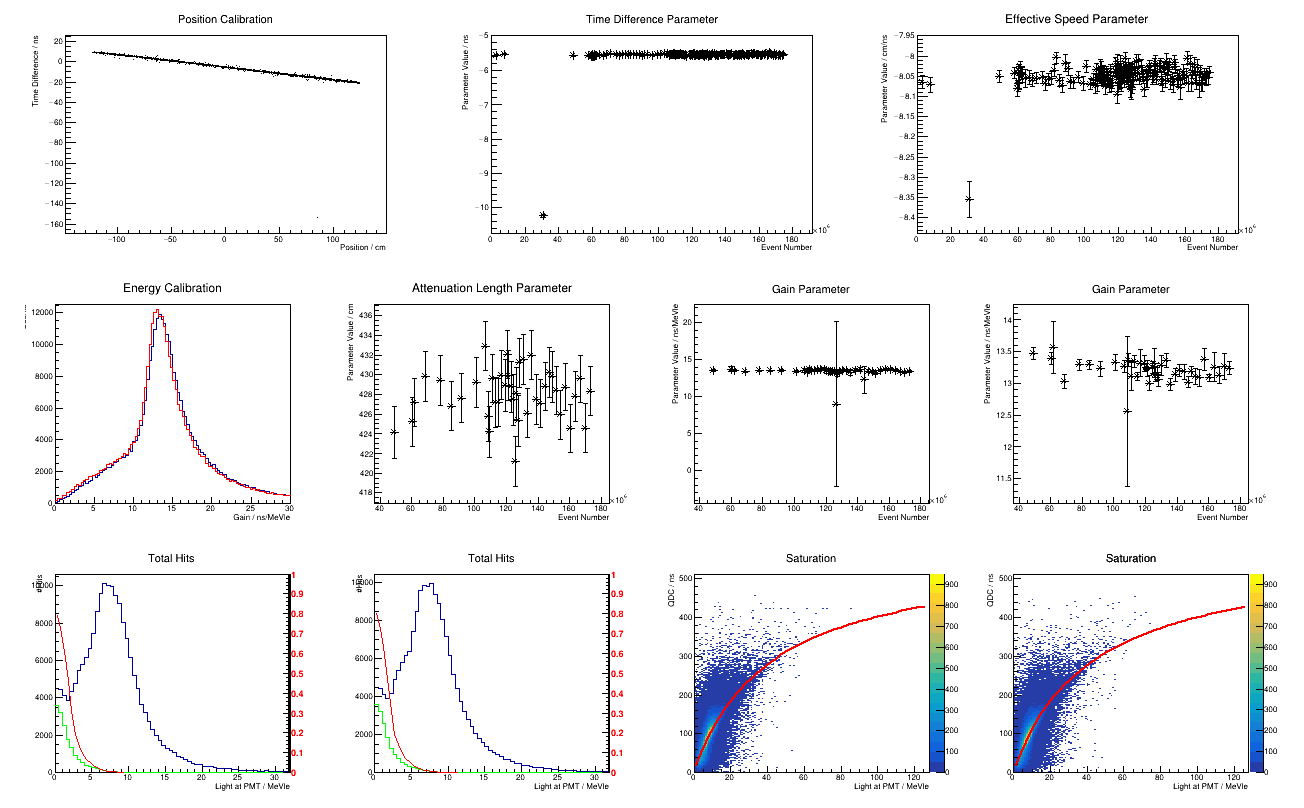

In [3]:
hist_dir = root_file.Get("Histograms/Plane_2")
hist_canvas = hist_dir.Get("Bar 70")
hist_canvas.Draw()

In [4]:
# hist_canvas.ls()
hists = []
pad2 = hist_canvas.GetPad(2).GetPad(1)
pad2.ls()
pris = pad2.GetListOfPrimitives()
for pri in pris:
    print(f"obj name: {pri.GetName()}, class name: {pri.ClassName()}, title name: {pri.GetTitle()}")
    if pri.GetTitle() == "Energy Calibration":
        hists.append(pri.Clone("hist"))

obj name: TFrame, class name: TFrame, title name: Pad graphics frame
obj name: , class name: TH1F, title name: Energy Calibration
obj name: , class name: TH1F, title name: Energy Calibration
obj name: title, class name: TPaveText, title name: PaveText. A Pave with several lines of text.
TPad fXlowNDC=0.01 fYlowNDC=0.01 fWNDC=0.23 fHNDC=0.98 Name= Bar 70_2_1 Title= Bar 70_2_1 Option=
 OBJ: TList	TList	Doubly linked list : 0
  TFrame  X1= 0.000000 Y1=0.000000 X2=30.000000 Y2=12518.100000
  OBJ: TH1F		Energy Calibration : 1 at: 0x56091cfaa320
  OBJ: TH1F		Energy Calibration : 1 at: 0x56091cfaa710
  OBJ: TPaveText	title  	X1= 7.311295 Y1=13053.726242 X2=22.688705 Y2=14004.624565


In [7]:
df1 = convert_1d_to_df(hists[0])
df1["label"] = "left PMT"
df2 = convert_1d_to_df(hists[1])
df2["label"] = "right PMT"

gain_df = pd.concat([df1, df2])

In [8]:
gain_df

,x,y,label
0,0.15,73.0,left PMT
1,0.45,105.0,left PMT
2,0.75,250.0,left PMT
3,1.05,276.0,left PMT
4,1.35,387.0,left PMT
...,...,...,...
95,28.65,532.0,right PMT
96,28.95,527.0,right PMT
97,29.25,472.0,right PMT
98,29.55,464.0,right PMT


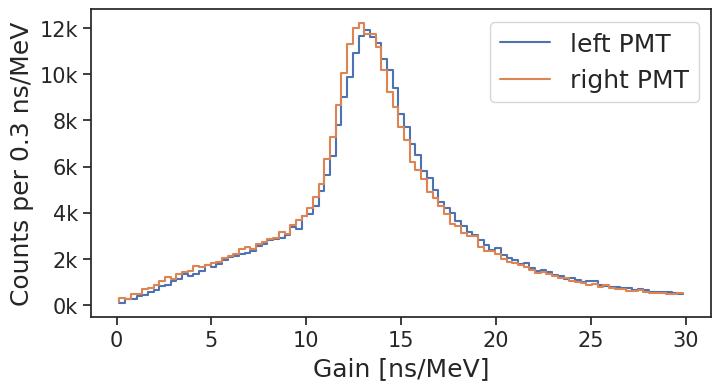

In [29]:
sns.set_theme(style = "ticks", rc={'figure.figsize':(8, 4)})
ax = sns.lineplot(data = gain_df, x = "x", y = "y", drawstyle='steps', hue = "label")
ax.get_yaxis().set_major_formatter(tkr.FuncFormatter(lambda x, p: f"{int(x/1000)}k"))
ax.set_ylabel("Counts per 0.3 ns/MeV", fontsize = 18)
ax.set_xlabel("Gain [ns/MeV]", fontsize = 18)
ax.tick_params(labelsize=15)
plt.legend(fontsize = 18)
plt.show()
ax.get_figure().savefig(fname=f"{dest_dir}/EnergyGain.png", bbox_inches="tight", dpi = 300)